# The objective of this project is to leverage customer financial and behavioral data to predict a customer’s Credit_Mix category using machine learning techniques. By developing and evaluating multiple classification models, the project aims to identify patterns that influence credit health and provide actionable insights to support informed credit decision-making, risk assessment, and long-term financial well-being.

In [1]:
#Importing the required libraries for the project.
import pandas as pd
pd.set_option('display.max_columns', None) #To see all columns in the data set
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px 
import string 

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, classification_report, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading the dataset from GitHub to ensure reproducibility and easy access to the data source.
url = 'https://raw.githubusercontent.com/toahirhussain/Predicting-Customer-Credit-Mix/refs/heads/main/Bank%20Data.csv'
df = pd.read_csv(url)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [3]:
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,8,29,5,"Personal Loan, Auto Loan, Mortgage Loan, Stude...",33,25,18.31,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,6,7,2_,"Auto Loan, and Student Loan",20,NaN,11.5,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,5,13.5,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,6,7,2_,"Auto Loan, and Student Loan",21,6_,11.5,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717
49999,0x25ff1,CUS_0x942c,December,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",22,5,11.5,7.0,_,502.38,34.108530,32 Years and 2 Months,No,35.104023,220.45787812168732,Low_spent_Medium_value_payments,360.37968260123847


Preserving the original dataset in its raw form while creating a duplicate dataset for preprocessing and modeling to ensure data integrity.

In [4]:
#Preserving the original dataset in its raw form while creating a duplicate dataset for preprocessing and modeling to ensure data integrity.
wdf = df.copy()

In [5]:
wdf.shape

(50000, 27)

In [6]:
wdf.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [7]:
wdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [8]:
wdf.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,48965.000000,50000.000000,50000.000000
mean,4182.004291,16.838260,22.921480,68.772640,21.052640,30.080200,32.279581,1491.304305
std,3174.109304,116.396848,129.314804,451.602363,14.860397,196.984121,5.106238,8595.647887
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.509652,0.000000
25%,1625.188333,3.000000,4.000000,8.000000,10.000000,4.000000,28.061040,32.222388
50%,3086.305000,6.000000,5.000000,13.000000,18.000000,7.000000,32.280390,74.733349
75%,5934.189094,7.000000,7.000000,20.000000,28.000000,10.000000,36.468591,176.157491
max,15204.633333,1798.000000,1499.000000,5799.000000,67.000000,2593.000000,48.540663,82398.000000


In [9]:
#Dropping Unnecessary column that have no impact to predict the model.
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']
wdf.drop(columns=cols_to_drop, inplace=True)

In [10]:
wdf['Age'] = wdf['Age'].str.strip(" -_")

In [11]:
wdf.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,December,24,Scientist,19114.12,NaN,3,4,3,4,4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,September,28,_______,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [12]:
#Converting credit history age to tatal months.
def convert_history_age(x):
    if pd.isnull(x):
        return np.nan
    parts = x.split()
    years = int(parts[0])
    months = int(parts[3])
    return (years * 12) + months

wdf['Credit_History_Age'] = wdf['Credit_History_Age'].apply(convert_history_age)

wdf['Credit_History_Age'].head()

0    273.0
1    274.0
2      NaN
3    276.0
4    327.0
Name: Credit_History_Age, dtype: float64

In [13]:
int_cols = ['Age', 'Num_Bank_Accounts', 'Num_Credit_Card',
            'Num_of_Loan', 'Delay_from_due_date',
            'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']

float_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Interest_Rate',
    'Changed_Credit_Limit', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

# convert integers
for col in int_cols:
    wdf[col] = pd.to_numeric(wdf[col], errors='coerce').astype('Int64')

# convert floats
for col in float_cols:
    wdf[col] = pd.to_numeric(wdf[col], errors='coerce')

In [14]:
#selecting all numeric column
num_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

In [15]:
wdf[num_cols].dtypes

Age                           Int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             Int64
Num_Credit_Card               Int64
Interest_Rate                 int64
Num_of_Loan                   Int64
Delay_from_due_date           Int64
Num_of_Delayed_Payment        Int64
Changed_Credit_Limit        float64
Num_Credit_Inquiries          Int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object

In [16]:
#Selecting all categorical columns
cat_cols = ['Month','Occupation', 'Payment_Behaviour', 'Payment_of_Min_Amount']

#making sure columns are string
wdf[cat_cols] = wdf[cat_cols].astype(str)

In [17]:
df[cat_cols].dtypes

Month                    object
Occupation               object
Payment_Behaviour        object
Payment_of_Min_Amount    object
dtype: object

In [18]:
for col in wdf.columns:
    if wdf[col].dtype == 'object':
        bad = wdf[col][wdf[col].str.contains(r'[^A-Za-z0-9\s@._-]', regex=True, na=False)]
        if not bad.empty:
            print(f"Column: {col}")
            print(bad.head())
            print("-" * 50)

Column: Payment_Behaviour
7      !@9#%8
36     !@9#%8
69     !@9#%8
84     !@9#%8
141    !@9#%8
Name: Payment_Behaviour, dtype: object
--------------------------------------------------


In [19]:
#Dropping invalid rows from Payment Behavious column.
wdf = wdf[wdf['Payment_Behaviour'] != '!@9#%8']

In [20]:
wdf.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022,Good,809.98,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4,Good,809.98,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4,Good,809.98,33.811894,NaN,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.675446
3,December,24,Scientist,19114.12,NaN,3,4,3,4,4,5,11.27,4,Good,809.98,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.826873
4,September,28,_______,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,Good,605.03,25.926822,327.0,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434


In [21]:
#From the dataset overview, we can see there is a invalid accupation type in occupation column. Let's check if there are more invalid accoupation type.
invalid_values = wdf['Occupation'].unique()
print(invalid_values)

['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']


In [22]:
#we only get one invalid occupation type. let's handle it.
#making the invalid accoupation to null.
wdf['Occupation'] = wdf['Occupation'].replace("_______", np.nan)

#filling only this null value with mode
wdf['Occupation'] = wdf['Occupation'].fillna(wdf['Occupation'].mode()[0])

In [23]:
wdf.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income               3254
Monthly_Inhand_Salary       6949
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2252
Delay_from_due_date            0
Num_of_Delayed_Payment      4543
Changed_Credit_Limit         977
Num_Credit_Inquiries         953
Credit_Mix                     0
Outstanding_Debt             454
Credit_Utilization_Ratio       0
Credit_History_Age          4103
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4132
Payment_Behaviour              0
Monthly_Balance              528
dtype: int64

# Handaling null values

In [24]:
##Missing values in Annual Income were imputed using the median salary of each occupation group 
#to preserve occupation-specific income patterns and reduce the influence of outliers.

wdf['Annual_Income'] = (
    wdf.groupby('Occupation')['Annual_Income']
       .transform(lambda x: x.fillna(x.median()))
)

#Missing values in Monthly_Inhand_Salary were imputed using the median salary of each occupation group 
#to preserve occupation-specific income patterns and reduce the influence of outliers.
wdf['Monthly_Inhand_Salary'] = (
    wdf.groupby('Occupation')['Monthly_Inhand_Salary']
       .transform(lambda x: x.fillna(x.median()))
)

# Num_of_Loan  → median after conversion
wdf['Num_of_Loan'] = wdf['Num_of_Loan'].fillna(
    wdf['Num_of_Loan'].median()
)

# Missing delayed payments → assume 0
wdf['Num_of_Delayed_Payment'] = wdf['Num_of_Delayed_Payment'].fillna(0)

wdf['Changed_Credit_Limit'] = wdf['Changed_Credit_Limit'].fillna(
    wdf['Changed_Credit_Limit'].median()
)

# Missing credit inquiries → assume 0
wdf['Num_Credit_Inquiries'] = wdf['Num_Credit_Inquiries'].fillna(0)

# Outstanding_Debt → median after conversion
wdf['Outstanding_Debt'] = wdf['Outstanding_Debt'].fillna(
    wdf['Outstanding_Debt'].median()
)

# Credit history → median after conversion
wdf['Credit_History_Age'] = wdf['Credit_History_Age'].fillna(
    wdf['Credit_History_Age'].median()
)

# Missing investment → assume 0
wdf['Amount_invested_monthly'] = wdf['Amount_invested_monthly'].fillna(0)

##Missing values in Monthly_Balance were imputed using the median salary of each occupation group 
#to preserve occupation-specific income patterns and reduce the influence of outliers.
wdf['Monthly_Balance'] = (
    wdf.groupby('Occupation')['Monthly_Balance']
       .transform(lambda x: x.fillna(x.median()))
)

In [25]:
wdf.head(7)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022,Good,809.98,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4,Good,809.98,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4,Good,809.98,33.811894,225.0,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.675446
3,December,24,Scientist,19114.12,3260.465000,3,4,3,4,4,5,11.27,4,Good,809.98,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.826873
4,September,28,Lawyer,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,Good,605.03,25.926822,327.0,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,October,28,Teacher,34847.84,3037.986667,2,4,6,1,3,3,5.42,5,Good,605.03,30.116600,328.0,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
6,November,28,Teacher,34847.84,3037.986667,2,4,6,1,3,0,5.42,5,_,605.03,30.996424,329.0,No,18.816215,72.680145,High_spent_Large_value_payments,452.302307


In [26]:
wdf.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [27]:
wdf["Credit_Mix"].unique()

array(['Good', '_', 'Standard', 'Bad'], dtype=object)

In [28]:
(wdf["Credit_Mix"] == "_").sum()

np.int64(9086)

In [29]:
#Dropping "_" values as it is a huge number and Credit Mix is our target variable.
wdf["Credit_Mix"] = wdf["Credit_Mix"].replace("_", np.nan)
wdf = wdf.dropna(subset=["Credit_Mix"])

In [30]:
wdf["Credit_Mix"].unique()

array(['Good', 'Standard', 'Bad'], dtype=object)

In [31]:
#Sanity check
print(len(wdf))
print(wdf["Credit_Mix"].value_counts())

37114
Credit_Mix
Standard    16970
Good        11290
Bad          8854
Name: count, dtype: int64


In [32]:
#Mapping target column
wdf["Credit_Mix"] = wdf["Credit_Mix"].map({
    "Bad": 0,
    "Standard": 1,
    "Good": 2
})

In [33]:
wdf["Credit_Mix"].isna().sum()      # should be 0
wdf["Credit_Mix"].unique()         # should be [0,1,2]
wdf["Credit_Mix"].value_counts()   # check class balance

Credit_Mix
1    16970
2    11290
0     8854
Name: count, dtype: int64

In [34]:
wdf.head(10)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022,2,809.980,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4,2,809.980,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4,2,809.980,33.811894,225.0,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.675446
3,December,24,Scientist,19114.12,3260.465000,3,4,3,4,4,5,11.27,4,2,809.980,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.826873
4,September,28,Lawyer,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,2,605.030,25.926822,327.0,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,October,28,Teacher,34847.84,3037.986667,2,4,6,1,3,3,5.42,5,2,605.030,30.116600,328.0,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
8,September,35,Engineer,143162.64,3221.851667,1,5,8,3,8,1942,7.10,3,2,1303.010,35.229707,221.0,No,246.992319,397.503654,Low_spent_Medium_value_payments,854.226027
9,October,35,Engineer,143162.64,12187.220000,1,5,8,3,6,3,2.10,3,2,1303.010,35.685836,222.0,No,246.992319,453.615131,Low_spent_Large_value_payments,788.114550
10,November,35,Engineer,143162.64,12187.220000,1,5,8,1381,8,5,7.10,5,2,1165.735,31.819845,223.0,No,246.992319,841.232236,Low_spent_Medium_value_payments,410.497445
11,December,35,Engineer,143162.64,12187.220000,1,5,8,3,8,6,7.10,5,2,1303.010,33.707169,225.0,No,246.992319,506.307780,High_spent_Medium_value_payments,715.421901


In [35]:
wdf.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [36]:
wdf.head(20)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022,2,809.980,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4,2,809.980,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4,2,809.980,33.811894,225.0,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.675446
3,December,24,Scientist,19114.12,3260.465000,3,4,3,4,4,5,11.27,4,2,809.980,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.826873
4,September,28,Lawyer,34847.84,3037.986667,2,4,6,1,3,1,5.42,5,2,605.030,25.926822,327.0,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,October,28,Teacher,34847.84,3037.986667,2,4,6,1,3,3,5.42,5,2,605.030,30.116600,328.0,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
8,September,35,Engineer,143162.64,3221.851667,1,5,8,3,8,1942,7.10,3,2,1303.010,35.229707,221.0,No,246.992319,397.503654,Low_spent_Medium_value_payments,854.226027
9,October,35,Engineer,143162.64,12187.220000,1,5,8,3,6,3,2.10,3,2,1303.010,35.685836,222.0,No,246.992319,453.615131,Low_spent_Large_value_payments,788.114550
10,November,35,Engineer,143162.64,12187.220000,1,5,8,1381,8,5,7.10,5,2,1165.735,31.819845,223.0,No,246.992319,841.232236,Low_spent_Medium_value_payments,410.497445
11,December,35,Engineer,143162.64,12187.220000,1,5,8,3,8,6,7.10,5,2,1303.010,33.707169,225.0,No,246.992319,506.307780,High_spent_Medium_value_payments,715.421901


The dataset has been thoroughly cleaned, and all necessary preprocessing steps have been completed to ensure data quality and consistency. With the data now properly prepared, it is ready to be split into training and testing sets for the next phase of model development and evaluation.

# Splitting Data into Train and Test

In [37]:
X = wdf[num_cols + cat_cols].copy()
y_encoded = wdf["Credit_Mix"].astype(int).copy()

# Map for display (edit to match your dataset)
label_map = {0: "Bad", 1: "Standard", 2: "Good"}

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=10,
    stratify=y_encoded
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Class distribution (train):')
print(y_train.value_counts(normalize=True))

Train shape: (25979, 21)  Test shape: (11135, 21)
Class distribution (train):
Credit_Mix
1    0.457254
2    0.304207
0    0.238539
Name: proportion, dtype: float64


In [39]:
# Capping outliers

def cap_outliers_train_test(X_train, X_test, numeric_cols, whisker=1.5):
    Xtr = X_train.copy()
    Xte = X_test.copy()

    for col in numeric_cols:
        # ✅ convert to float so clip bounds like 11.5 don't break Int64 columns
        Xtr[col] = Xtr[col].astype("float64")
        Xte[col] = Xte[col].astype("float64")

        q1 = Xtr[col].quantile(0.25)
        q3 = Xtr[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - whisker * iqr
        upper = q3 + whisker * iqr

        Xtr[col] = Xtr[col].clip(lower, upper)
        Xte[col] = Xte[col].clip(lower, upper)

    return Xtr, Xte


X_train, X_test = cap_outliers_train_test(X_train, X_test, num_cols)


In [40]:
# Preprocessing pipeline (impute -> scale numeric, impute -> one-hot categorical)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)


In [41]:
# Evaluation helpers

def evaluate_model(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)

    # AUC support (multi-class): use predict_proba if available
    auc = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)
        try:
            auc = roc_auc_score(y_eval, y_score, multi_class="ovr", average="macro")
        except Exception:
            auc = None

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision (macro)": precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "AUC-ROC (macro, ovr)": auc,
    }


def show_classification_details(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)
    print(title)
    print(classification_report(y_eval, y_pred))
    cm = confusion_matrix(y_eval, y_pred)

    fig, ax = plt.subplots(figsize=(15, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # annotate
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center')

    plt.tight_layout()
    plt.show()


## Train baseline models using pipelines

Because preprocessing is inside the pipeline, the workflow is leak-free (and CV is correct by default).


In [42]:
# Define models (wrapped in pipelines)
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=10))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=10))
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            random_state=10,
            eval_metric="mlogloss",
            n_estimators=300,
            learning_rate=0.08,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9
        ))
    ]),
}

# Fit + evaluate
baseline_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    baseline_results.append(evaluate_model(model, X_test, y_test, name))

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 (macro)", ascending=False)
baseline_df


,Model,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),"AUC-ROC (macro, ovr)"
3,XGBoost,0.965065,0.966723,0.965174,0.966723,0.965937,0.997448
1,Random Forest,0.956713,0.959670,0.956244,0.959670,0.957911,0.996334
2,Gradient Boosting,0.942434,0.944739,0.943378,0.944739,0.944051,0.994173
0,Logistic Regression,0.889897,0.895918,0.889391,0.895918,0.892477,0.979263


Best baseline: XGBoost
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2657
           1       0.96      0.96      0.96      5091
           2       0.97      0.97      0.97      3387

    accuracy                           0.97     11135
   macro avg       0.97      0.97      0.97     11135
weighted avg       0.97      0.97      0.97     11135



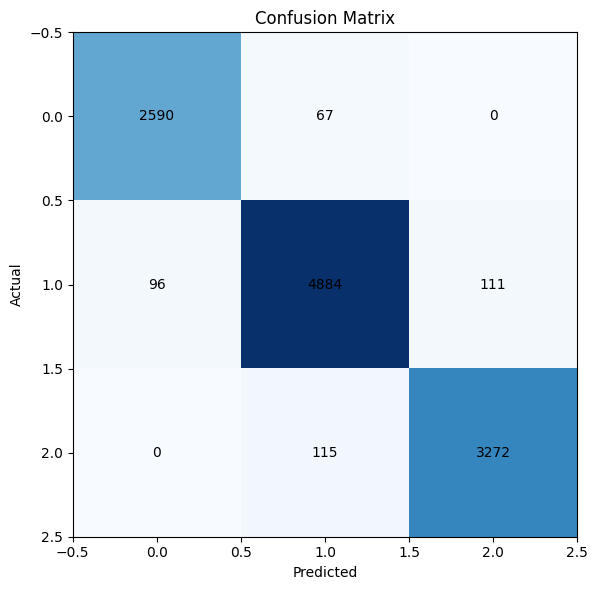

In [43]:
# (Optional) Print a detailed report for the current best baseline model
best_baseline_name = baseline_df.iloc[0]["Model"]
best_baseline_model = models[best_baseline_name]

show_classification_details(best_baseline_model, X_test, y_test, f"Best baseline: {best_baseline_name}")


## Cross-validation (correct, leak-free)

Cross-validation now evaluates the *entire* pipeline inside each fold.


In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y_encoded, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Balanced Acc": scores["test_balanced_accuracy"].mean(),
        "CV Precision (macro)": scores["test_precision_macro"].mean(),
        "CV Recall (macro)": scores["test_recall_macro"].mean(),
        "CV F1 (macro)": scores["test_f1_macro"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV F1 (macro)", ascending=False)
cv_df


,Model,CV Accuracy,CV Balanced Acc,CV Precision (macro),CV Recall (macro),CV F1 (macro)
3,XGBoost,0.965862,0.967067,0.966724,0.967067,0.966890
1,Random Forest,0.959880,0.962461,0.959924,0.962461,0.961165
2,Gradient Boosting,0.939753,0.941955,0.941317,0.941955,0.941621
0,Logistic Regression,0.835507,0.847561,0.837280,0.847561,0.840847


## Hyperparameter tuning


In [46]:
# Tune Random Forest
rf_pipe = models["Random Forest"]

rf_param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV F1:', rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best RF CV F1: 0.9567876558930472


In [47]:
# Tune XGBoost
xgb_pipe = models["XGBoost"]

xgb_param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
print('Best XGB params:', xgb_grid.best_params_)
print('Best XGB CV F1:', xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Best XGB params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 600, 'model__subsample': 1.0}
Best XGB CV F1: 0.9677582510893068


In [48]:
# Compare tuned models on the held-out test set

tuned_models = {
    "Random Forest (tuned)": best_rf,
    "XGBoost (tuned)": best_xgb,
    "Best Baseline": best_baseline_model,
}

tuned_results = []
for name, model in tuned_models.items():
    tuned_results.append(evaluate_model(model, X_test, y_test, name))

tuned_df = pd.DataFrame(tuned_results).sort_values("F1 (macro)", ascending=False)
tuned_df


,Model,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),"AUC-ROC (macro, ovr)"
1,XGBoost (tuned),0.969645,0.971201,0.969615,0.971201,0.970399,0.997958
2,Best Baseline,0.965065,0.966723,0.965174,0.966723,0.965937,0.997448
0,Random Forest (tuned),0.958419,0.960869,0.958318,0.960869,0.959561,0.996512


Best tuned model: XGBoost (tuned)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2657
           1       0.97      0.96      0.97      5091
           2       0.97      0.97      0.97      3387

    accuracy                           0.97     11135
   macro avg       0.97      0.97      0.97     11135
weighted avg       0.97      0.97      0.97     11135



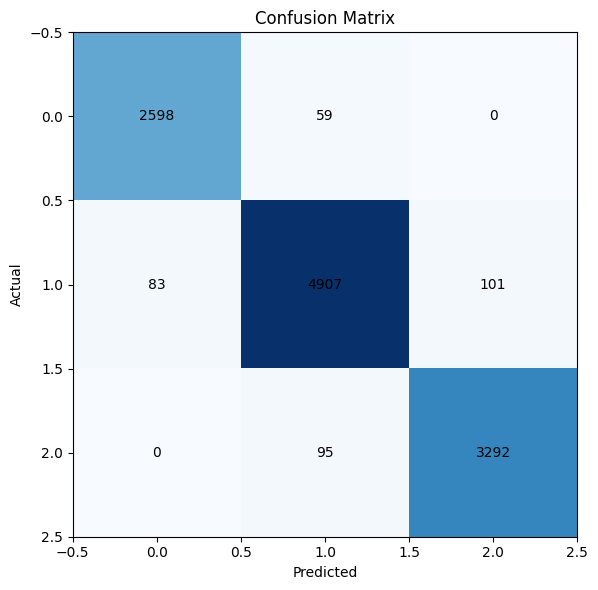

In [49]:
# Detailed report for best tuned model
best_tuned_name = tuned_df.iloc[0]["Model"]
best_tuned_model = tuned_models[best_tuned_name]

show_classification_details(best_tuned_model, X_test, y_test, f"Best tuned model: {best_tuned_name}")


## Final model comparison

In [50]:
final_compare = pd.concat([
    baseline_df.assign(Type="Baseline"),
    tuned_df.assign(Type="Tuned")
], ignore_index=True)

final_compare.sort_values(["Type", "F1 (macro)"], ascending=[True, False])

,Model,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),"AUC-ROC (macro, ovr)",Type
0,XGBoost,0.965065,0.966723,0.965174,0.966723,0.965937,0.997448,Baseline
1,Random Forest,0.956713,0.959670,0.956244,0.959670,0.957911,0.996334,Baseline
2,Gradient Boosting,0.942434,0.944739,0.943378,0.944739,0.944051,0.994173,Baseline
3,Logistic Regression,0.889897,0.895918,0.889391,0.895918,0.892477,0.979263,Baseline
4,XGBoost (tuned),0.969645,0.971201,0.969615,0.971201,0.970399,0.997958,Tuned
5,Best Baseline,0.965065,0.966723,0.965174,0.966723,0.965937,0.997448,Tuned
6,Random Forest (tuned),0.958419,0.960869,0.958318,0.960869,0.959561,0.996512,Tuned


## Feature impact (permutation importance)


In [51]:
# Permutation Importance

pre = best_tuned_model.named_steps["preprocess"]
final_est = best_tuned_model.named_steps["model"]

# Transform X_test into the feature space the model uses
X_test_trans = pre.transform(X_test)

# Feature names in transformed space
feature_names = pre.get_feature_names_out()

# Permutation importance on final estimator
perm = permutation_importance(
    final_est,
    X_test_trans,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(25))

,feature_transformed,importance_mean,importance_std
5,num__Interest_Rate,0.146786,0.001950
44,cat__Payment_of_Min_Amount_Yes,0.108164,0.001060
11,num__Outstanding_Debt,0.090987,0.002876
8,num__Num_of_Delayed_Payment,0.056352,0.002109
3,num__Num_Bank_Accounts,0.050000,0.001083
7,num__Delay_from_due_date,0.034274,0.001549
9,num__Changed_Credit_Limit,0.030638,0.001312
13,num__Credit_History_Age,0.015131,0.000850
6,num__Num_of_Loan,0.007251,0.000584
4,num__Num_Credit_Card,0.007030,0.000797


In [52]:
# Sort categorical columns by length so longest matches first
cat_cols_sorted = sorted(cat_cols, key=len, reverse=True)

def base_feature_name(transformed_name: str) -> str:
    f = str(transformed_name)

    # Numeric transformer features keep original numeric column name
    if f.startswith("num__"):
        return f.replace("num__", "")

    # Categorical transformer features: cat__<origcol>_<category>
    if f.startswith("cat__"):
        f2 = f.replace("cat__", "")

        # Identify which original categorical column this feature came from
        for col in cat_cols_sorted:
            if f2 == col or f2.startswith(col + "_"):
                return col

        # Fallback (rare)
        return f2.split("_")[0]

    # If no prefix, return as-is
    return f


imp_df["base_feature"] = imp_df["feature_transformed"].apply(base_feature_name)

base_imp = (
    imp_df.groupby("base_feature")["importance_mean"]
    .sum()
    .sort_values(ascending=False)
)


In [53]:
top15 = base_imp.head(15).index.tolist()

print("Top 15 base features:")
print(top15)

# Safety check: top15 must exist in wdf columns
missing = [c for c in top15 if c not in wdf.columns]
print("Missing from wdf:", missing)

Top 15 base features:
['Interest_Rate', 'Payment_of_Min_Amount', 'Outstanding_Debt', 'Num_of_Delayed_Payment', 'Num_Bank_Accounts', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Credit_History_Age', 'Num_of_Loan', 'Num_Credit_Card', 'Age', 'Total_EMI_per_month', 'Num_Credit_Inquiries', 'Annual_Income', 'Occupation']
Missing from wdf: []


In [54]:
# Train final model using only Top 15 features

X_reduced = wdf[top15].copy()

# Use encoded target for XGBoost (recommended)
y_final = y_encoded

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_final,
    test_size=0.30,
    random_state=10,
    stratify=y_final
)

In [55]:
top_num_cols = [c for c in top15 if c in num_cols]
top_cat_cols = [c for c in top15 if c in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_top15 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, top_num_cols),
        ("cat", categorical_transformer, top_cat_cols)
    ],
    remainder="drop"
)

final_top15_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_top15),
    ("model", XGBClassifier(
        random_state=10,
        eval_metric="mlogloss",
        objective="multi:softprob",
        num_class=len(np.unique(y_final))
    ))
])

final_top15_pipeline.fit(X_train_r, y_train_r)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
# Evaluation

y_pred_r = final_top15_pipeline.predict(X_test_r)

In [57]:
y_test_lbl = pd.Series(y_test_r).map(label_map)
y_pred_lbl = pd.Series(y_pred_r).map(label_map)

print(classification_report(y_test_lbl, y_pred_lbl))

              precision    recall  f1-score   support

         Bad       0.97      0.98      0.98      2657
        Good       0.97      0.97      0.97      3387
    Standard       0.97      0.97      0.97      5091

    accuracy                           0.97     11135
   macro avg       0.97      0.97      0.97     11135
weighted avg       0.97      0.97      0.97     11135



In [58]:
# Deployment sanity check: single-row prediction
sample = X_reduced.iloc[[0]].copy()  # keep DataFrame shape (1 row)

pred_enc = final_top15_pipeline.predict(sample)[0]
print("Predicted label:", label_map[int(pred_enc)])


Predicted label: Good


## Save artifacts for deployment

In [59]:
# Save model + feature list + encoder

joblib.dump(final_top15_pipeline, "credit_mix_pipeline_top15.joblib")
joblib.dump(top15, "top15_features.joblib")
joblib.dump(label_map, "label_map.joblib")

# ✅ Save schema for Streamlit (super important)
schema = {
    "top15": top15,
    "top_num_cols": top_num_cols,
    "top_cat_cols": top_cat_cols
}
joblib.dump(schema, "top15_schema.joblib")

print("Saved artifacts:")
print("- credit_mix_pipeline_top15.joblib")
print("- top15_features.joblib")
print("- label_map.joblib")
print("- top15_schema.joblib")


Saved artifacts:
- credit_mix_pipeline_top15.joblib
- top15_features.joblib
- label_map.joblib
- top15_schema.joblib


In [60]:
import os
for f in ["credit_mix_pipeline_top15.joblib","top15_features.joblib","label_map.joblib","top15_schema.joblib"]:
    print(f, "exists?", os.path.exists(f))

credit_mix_pipeline_top15.joblib exists? True
top15_features.joblib exists? True
label_map.joblib exists? True
top15_schema.joblib exists? True


# Business interpretation

How this can be used in a real business setting:

- **Decision support:** Predicting Credit Mix (Bad/Standard/Good) helps segment customers for credit offers, limit reviews, and risk controls.
- **Early intervention:** Customers drifting toward **Bad** can trigger proactive actions (reminders, repayment plan options, tailored education).
- **Portfolio strategy:** Aggregate predictions can help the business track risk distribution and adjust underwriting thresholds.

What to call out from feature importance:

- Highlight the top drivers (for example: utilization, outstanding debt, payment delays, number of credit cards, credit history age).
- Translate each driver into a business explanation (behavioral risk, affordability, repayment consistency).

Model risk and limitations (important to mention):

- Monitor for data drift and retrain periodically.
- Avoid using sensitive or proxy features in ways that could create unfair outcomes.
- Use human review for adverse decisions.


# Project Summary

### Modeling approach
- Cleaned and validated raw fields (types, missing values, inconsistent tokens)
- Built leak-free preprocessing with `ColumnTransformer` + `Pipeline`
- Trained multiple models and selected the best based on macro F1 and balanced accuracy
- Tuned key models with `GridSearchCV`
- Used permutation importance for interpretability

### Results summary
- Best models are compared on a held-out test set
- Cross-validation confirms performance stability

### Recommendations
- Deploy as a scoring service (batch or API)
- Add monitoring for drift and periodic retraining
- Add a threshold-based business policy layer (actions per predicted class)
